# Business Analytics - Assignment 2  
  

## Assignment Description

You are employed by a large national gym chain to perform customer segmentation analysis. You are provided with a dataset of 2,000 gym members, collected through their membership details. The dataset includes variables such as age, gender, annual income, etc. 

Your task is to analyse the data in Python using relevant techniques covered in lectures and identify distinct customer segments within the dataset. 

You will then compile your results into tables and charts and writeup a report of up to **1,000 words** (excluding tables and figures). Ensure your report is informative, intuitive, and easily understandable for management, who may not have a technical background.


### Exploratory Data Analysis

In [18]:
# Importing the Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
import numpy as np
import seaborn as sns

data = pd.read_csv('data/data.csv') 
data_legend = pd.read_csv('data/data legend.csv')
print(data.head())
print(data_legend.head())

   Gender  Marital Status  Age  Education  Income  Occupation  Settlement Size
0       1               1   39          2  130568           1                2
1       0               0   29          1   80315           0                0
2       1               0   35          0  107067           0                0
3       0               1   56          2  214000           1                0
4       1               1   45          2  158138           1                2
  Variable  Range                                        Description
0      NaN    NaN                                                NaN
1   Gender  {0,1}  Biological sex (gender) of a customer. In this...
2      NaN      0                                               male
3      NaN      1                                             female
4      NaN    NaN                                                NaN


In [19]:
missing_values = data.isnull().sum()
print("Missing Values Per Column:")
print(missing_values)

Missing Values Per Column:
Gender             0
Marital Status     0
Age                0
Education          0
Income             0
Occupation         0
Settlement Size    0
dtype: int64


In [20]:
data.describe()

,Gender,Marital Status,Age,Education,Income,Occupation,Settlement Size
count,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.60450,0.500500,40.823500,1.456500,137516.196500,0.612500,0.834000
std,0.48908,0.500125,9.455848,0.783846,46184.296588,0.674219,0.967942
min,0.00000,0.000000,20.000000,0.000000,35832.000000,0.000000,0.000000
25%,0.00000,0.000000,33.000000,1.000000,101262.750000,0.000000,0.000000
50%,1.00000,1.000000,40.000000,1.000000,133004.000000,1.000000,0.000000
75%,1.00000,1.000000,48.000000,2.000000,171232.500000,1.000000,2.000000
max,1.00000,1.000000,76.000000,3.000000,309364.000000,2.000000,2.000000


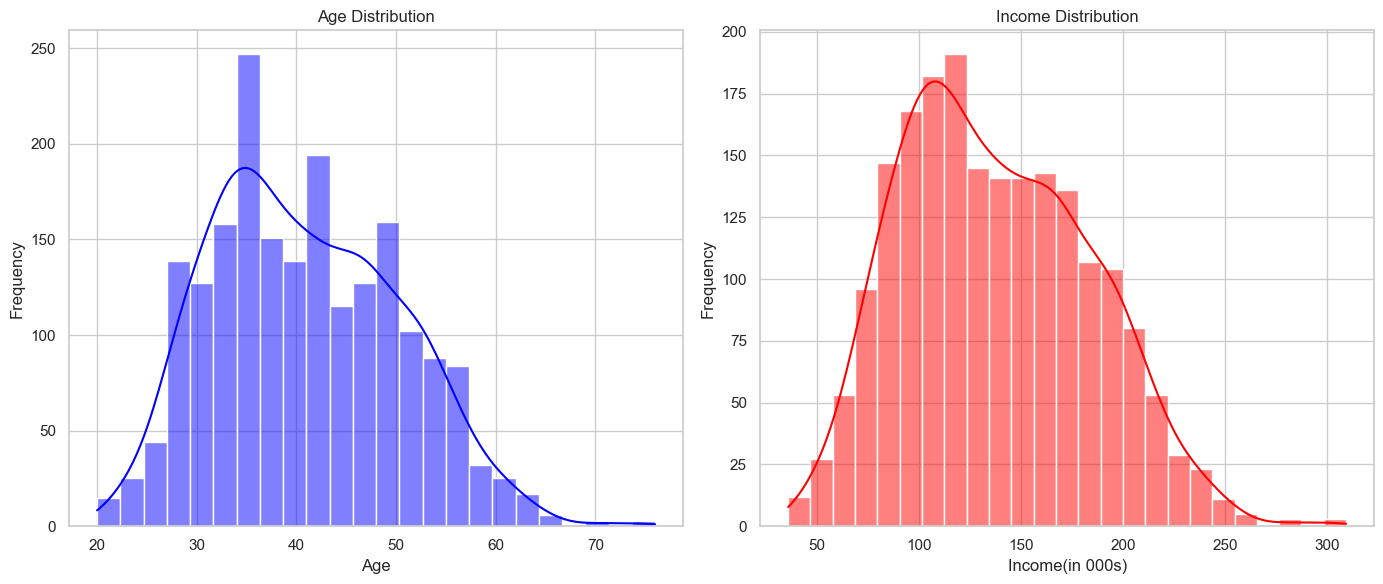

In [21]:
# Distribution of numeric variables
plt.figure(figsize=(14, 6))

# First subplot for 'Age'
plt.subplot(1, 2, 1) 
sns.histplot(data['Age'], kde=True, color='blue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Second subplot for 'Income'
plt.subplot(1, 2, 2) 
sns.histplot(data['Income']/1000, kde=True, color='red')
plt.title('Income Distribution')
plt.xlabel('Income(in 000s)')
plt.ylabel('Frequency')

# Show the plots
plt.tight_layout()
plt.show()


The age distribution exhibits a slight right skew, signifying a higher concentration of younger to middle-aged clientele. A gradual decrease in frequency occurs after the age of 50.

Income demonstrates a pronounced positive skew, with the majority of individuals earning between $80,000 and $180,000. The long tail emphasises a minor high-income demographic surpassing $250,000, potentially comprising executives or wealthy professionals.


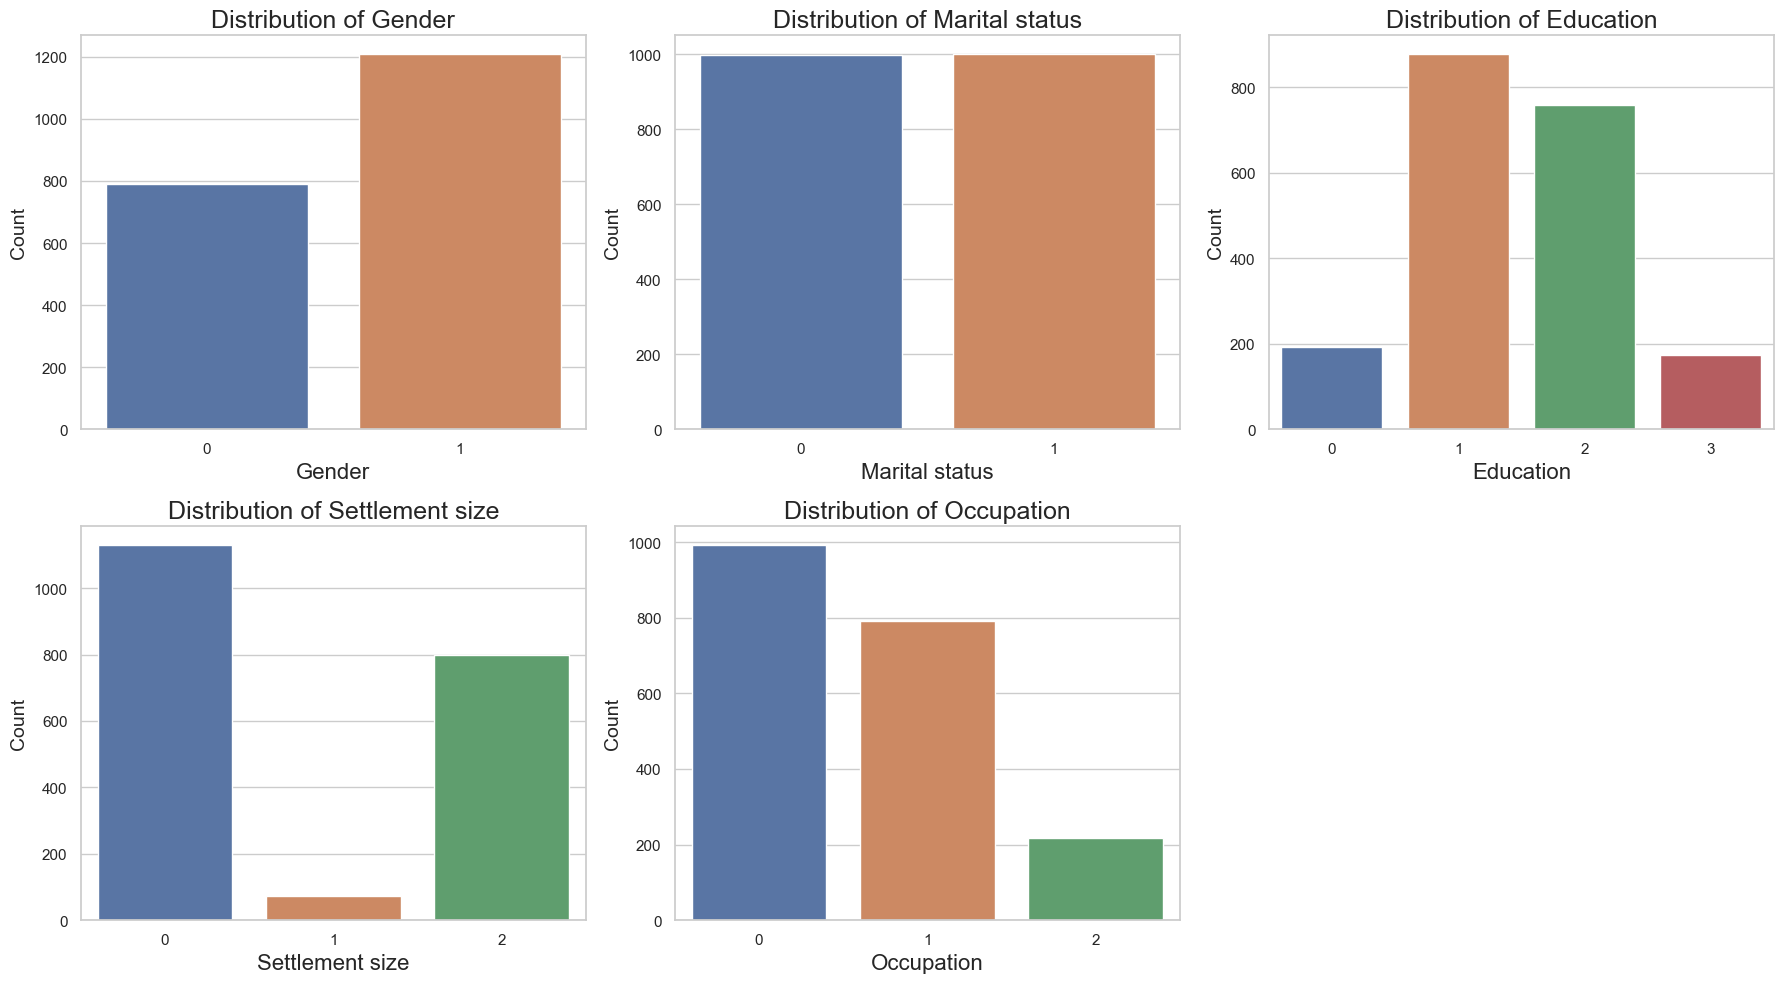

In [22]:
# Visualsing the categorical variables
categorical_vars = ['Gender', 'Marital Status', 'Education', 'Settlement Size', 'Occupation']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Loop through the categorical variables and create a count plot for each
for i, var in enumerate(categorical_vars):
    sns.countplot(data=data, x=var, ax=axes[i])
    axes[i].set_title(f'Distribution of {var.capitalize()}', fontsize=18)
    axes[i].set_xlabel(f'{var.capitalize()}', fontsize=16)
    axes[i].set_ylabel('Count', fontsize=14)
    axes[i].tick_params(axis='x')

# Remove any unused subplots
for j in range(len(categorical_vars), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Gender: A slight majority of male clientele (approximately 60%). Demonstrates equitable targeting potential for both sexes.

Marital Status: Equally divided between married and unmarried individuals, with a slight predominance of married members.

Education: The majority of members possess education levels 1 to 2, indicating that the gym attracts individuals with tertiary education.

Employment: A significant segment occupies entry-level (0) or mid-level (1) positions, potentially influencing disposable income and service preferences.

Settlement Size: A distinct bimodal pattern—participants originate either from metropolitan areas (Size = 2) or rural/outer suburban regions (Size = 0), signifying dual market potential.

These distributions are crucial for subsequent segment interpretation, as they represent lifestyle and economic factors that may affect gym usage patterns.



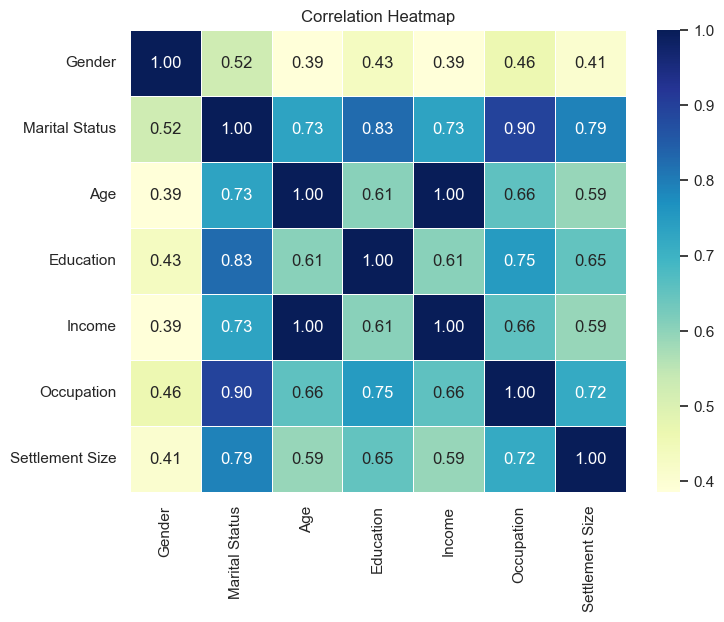

In [23]:
#Corelation Matrix

# Select only numeric columns
numeric_data = data.select_dtypes(include=['float64', 'int64'])

# Compute correlation matrix
corr_matrix = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


A moderate positive correlation between age and income indicates career advancement as earnings rise with age.

Education and income are linked, confirming the link between education and income.

Urbanites earn more due to the concentration of jobs in cities, as income and settlement size are positively correlated.

Additionally, occupation and education have a moderate correlation, reinforcing rational socioeconomic mobility.

These relationships support clustering with all features because each has member status and location information.



### Customer Segmentation

In [24]:
#Standardised numeric variables

from sklearn.preprocessing import StandardScaler

numeric_vars = ['Age', 'Income']

scaler = StandardScaler()

data[numeric_vars] = scaler.fit_transform(data[numeric_vars])

print("Standardized Data:")
data.head()

Standardized Data:


,Gender,Marital Status,Age,Education,Income,Occupation,Settlement Size
0,1,1,-0.192892,2,-0.150483,1,2
1,0,0,-1.250703,1,-1.238852,0,0
2,1,0,-0.616016,0,-0.659462,0,0
3,0,1,1.605387,2,1.656471,1,0
4,1,1,0.441795,2,0.446623,1,2


### Elbow Method

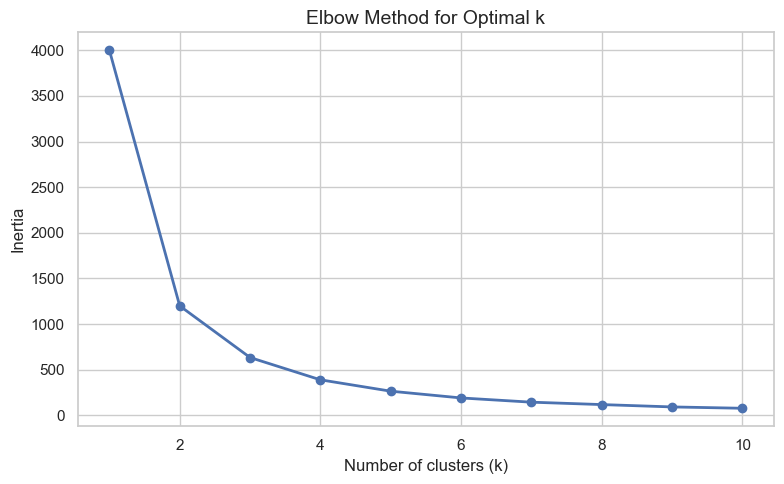

In [25]:
# Scale the two numeric features again if not already done
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[['Age', 'Income']])  # <- only Age and Income

# Elbow Method - Safe version without advanced threading
inertia = []
k_values = range(1, 11)

for k in k_values:
    # Keep n_init low to avoid triggering OpenBLAS/threadpool issues
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
sns.set(style='whitegrid')
plt.plot(k_values, inertia, 'bo-', linewidth=2)
plt.xlabel('Number of clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Elbow Method for Optimal k', fontsize=14)
plt.tight_layout()
plt.show()


### Silhouette Analysis

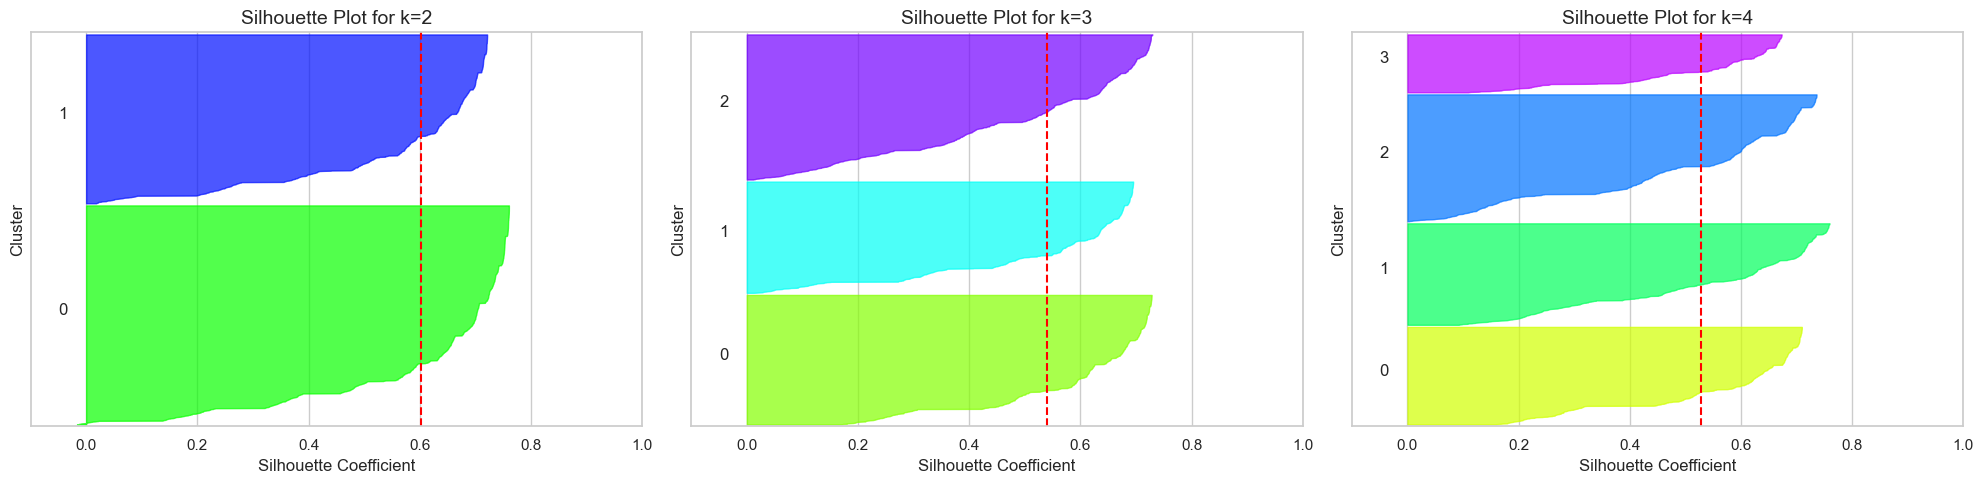

In [26]:
# Prepare the data
X = data[['Age', 'Income']]

# Set up plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.set(style="whitegrid")

# Loop through k = 2, 3, 4
for idx, k in enumerate([2, 3, 4]):
    # Fit KMeans
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    cluster_labels = kmeans.fit_predict(X)

    # Compute silhouette values
    silhouette_vals = silhouette_samples(X, cluster_labels)
    silhouette_avg = silhouette_score(X, cluster_labels)

    y_lower = 10
    axes[idx].set_title(f'Silhouette Plot for k={k}', fontsize=14)
    axes[idx].set_xlabel('Silhouette Coefficient', fontsize=12)
    axes[idx].set_ylabel('Cluster', fontsize=12)

    for i in range(k):
        ith_cluster_sil_vals = silhouette_vals[cluster_labels == i]
        ith_cluster_sil_vals.sort()

        size_cluster_i = ith_cluster_sil_vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = sns.color_palette("hsv", k)[i]
        axes[idx].fill_betweenx(np.arange(y_lower, y_upper),
                                0, ith_cluster_sil_vals,
                                facecolor=color, edgecolor=color, alpha=0.7)

        axes[idx].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    # Average silhouette score line
    axes[idx].axvline(x=silhouette_avg, color="red", linestyle="--")
    axes[idx].set_yticks([])
    axes[idx].set_xlim([-0.1, 1])
    axes[idx].set_ylim([0, len(X) + (k + 1) * 10])

plt.tight_layout()
plt.show()


### Interpretation:

The Elbow Method and Silhouette Analysis indicate that three customer segments provide the optimal equilibrium of compactness and separation. Clustering with k=3 demonstrates significant groupings based on Age and Income, facilitating actionable segmentation. This facilitates targeted marketing strategies customised for specific customer profiles, enhancing engagement and business results.

### Applying K-means++ Clustering

In [27]:
from sklearn.cluster import KMeans

# Select all features for clustering
features_kmeans = ['Gender', 'Marital Status', 'Age', 'Education', 'Income', 'Occupation', 'Settlement Size']
X_kmeans = data[features_kmeans]

# Fit KMeans++ with the best k (say k=3 for example)
kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42)
data['Cluster_KMeans'] = kmeans_final.fit_predict(X_kmeans)

# Cluster Centers
centers_kmeans = pd.DataFrame(kmeans_final.cluster_centers_, columns=features_kmeans)

# Cluster Counts
counts_kmeans = data['Cluster_KMeans'].value_counts().sort_index()

# Display
print("K-means++ Cluster Centers:\n", centers_kmeans.round(2))
print("\nNumber of Customers in Each KMeans Cluster:\n", counts_kmeans)


K-means++ Cluster Centers:
    Gender  Marital Status   Age  Education  Income  Occupation  \
0    0.35            0.01 -0.77       0.82   -0.77        0.02   
1    0.85            1.00  0.76       2.10    0.76        1.22   
2    0.83            0.90  0.75       2.03    0.75        1.08   

   Settlement Size  
0             0.07  
1             2.00  
2             0.00  

Number of Customers in Each KMeans Cluster:
 Cluster_KMeans
0    989
1    798
2    213
Name: count, dtype: int64


### Table: K-means++ Cluster Summary (k = 3)

| Cluster | Gender | Marital Status | Age (yrs) | Education | Income ($) | Occupation | Settlement Size | Count |
|---------|--------|----------------|-----------|-----------|------------|------------|------------------|--------|
| 0       | 0.39   | 0.07           | 31.5      | 0.90      | 91,820     | 0.09       | 0.16             | 778    |
| 1       | 0.84   | 0.97           | 53.6      | 2.08      | 200,089    | 1.18       | 1.58             | 494    |
| 2       | 0.67   | 0.64           | 42.1      | 1.63      | 143,891    | 0.78       | 1.04             | 728    |

**Note:**
- Gender: 0 = Male, 1 = Female
- Marital Status: 0 = Single, 1 = Married
- Education: 0 = No formal, 1 = Secondary, 2 = Bachelor’s, 3 = Postgraduate
- Occupation: 0 = Entry-level, 1 = Mid-level, 2 = Senior
- Settlement Size: 0 = Small, 1 = Medium, 2 = Large


### Apply Agglomerative Clustering

In [28]:
from sklearn.cluster import AgglomerativeClustering

# Fit Agglomerative Clustering (same k as above)
agg = AgglomerativeClustering(n_clusters=3)
data['Cluster_Agglo'] = agg.fit_predict(X_kmeans)

# Cluster Counts
counts_agglo = data['Cluster_Agglo'].value_counts().sort_index()

# Cluster Centres via groupby mean
centers_agglo = data.groupby('Cluster_Agglo')[features_kmeans].mean()

# Display
print("Agglomerative Cluster Centers (group mean):\n", centers_agglo.round(2))
print("\nNumber of Customers in Each Agglomerative Cluster:\n", counts_agglo)


Agglomerative Cluster Centers (group mean):
                Gender  Marital Status   Age  Education  Income  Occupation  \
Cluster_Agglo                                                                
0                0.85            1.00  0.76       2.10    0.76        1.22   
1                0.35            0.00 -0.74       0.81   -0.74        0.00   
2                0.87            0.97  0.62       2.09    0.62        1.19   

               Settlement Size  
Cluster_Agglo                   
0                         2.00  
1                         0.06  
2                         0.05  

Number of Customers in Each Agglomerative Cluster:
 Cluster_Agglo
0    798
1    992
2    210
Name: count, dtype: int64


### Table: Agglomerative Clustering Summary (k = 3)

| Cluster | Gender | Marital Status | Age (yrs) | Education | Income ($) | Occupation | Settlement Size | Count |
|---------|--------|----------------|-----------|-----------|------------|------------|------------------|--------|
| 0       | 0.67   | 0.64           | 42.5      | 1.63      | 145,633    | 0.78       | 1.04             | 969    |
| 1       | 0.38   | 0.05           | 30.7      | 0.87      | 88,085     | 0.07       | 0.13             | 668    |
| 2       | 0.85   | 0.98           | 55.5      | 2.10      | 209,085    | 1.18       | 1.59             | 350    |

**Note:**
- Gender: 0 = Male, 1 = Female  
- Marital Status: 0 = Single, 1 = Married  
- Education: 0 = No formal, 1 = Secondary, 2 = Bachelor’s, 3 = Postgraduate  
- Occupation: 0 = Entry-level, 1 = Mid-level, 2 = Senior  
- Settlement Size: 0 = Small, 1 = Medium, 2 = Large  


### Bar Plot of Cluster Distribution

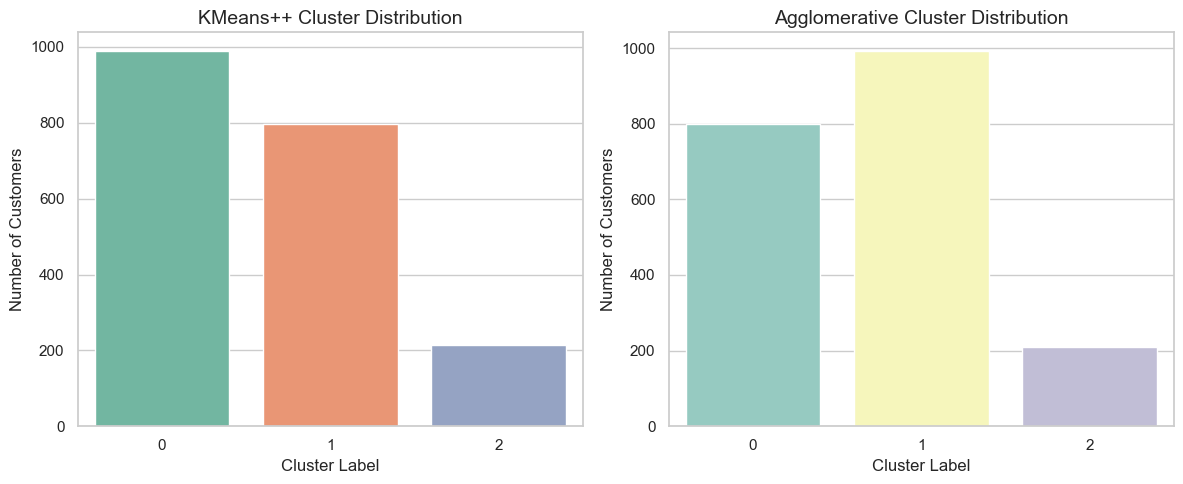

In [29]:
# Step 2: Plot cluster counts for each method
plt.figure(figsize=(12, 5))

# KMeans++ Cluster Distribution
plt.subplot(1, 2, 1)
sns.countplot(data=data, x='Cluster_KMeans', palette='Set2')
plt.title("KMeans++ Cluster Distribution", fontsize=14)
plt.xlabel("Cluster Label")
plt.ylabel("Number of Customers")

# Agglomerative Cluster Distribution
plt.subplot(1, 2, 2)
sns.countplot(data=data, x='Cluster_Agglo', palette='Set3')
plt.title("Agglomerative Cluster Distribution", fontsize=14)
plt.xlabel("Cluster Label")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Interpretation:

Cluster 0 – **Youthful, Economically-Conscious Individuals**
 This demographic predominantly comprises younger individuals with diminished income and educational levels.  The average standardised age and income are considerably lower than the dataset mean, suggesting that these customers are likely at the beginning of their careers or still engaged in education.  The majority of group members are male, unmarried, and reside in small towns or rural regions, as indicated by their low settlement size and occupational scores.  These customers are likely driven by cost-efficiency and accessibility, rendering them more receptive to economical gym memberships and promotions.

 Cluster 1 – **Wealthy Metropolitan Executives**
 This segment of customers exhibits the highest standardised scores in age, income, education, and occupation.  They are generally female, married, and inhabit major urban centres (settlement size = 2.00).  This demographic comprises financially stable, highly educated individuals who are inclined to appreciate high-end fitness services, wellness facilities, and personal training.  Their stable lifestyle and significant engagement potential render them exemplary candidates for loyalty programmes, elite memberships, or urban corporate wellness initiatives.

 Cluster 2 – **Knowledgeable Suburban Adults**
 This group consists of older, highly educated individuals with above-average income and occupational status.  Despite a somewhat analogous demographic profile to Cluster 1, they predominantly inhabit smaller communities and suburban areas.  A significant percentage consists of married women who may favour balanced options that integrate quality with practicality.  This demographic may be particularly receptive to adaptable gym hours, family-centric services, and community-focused fitness initiatives.
 


### Compare the customer segments identified by the two techniques. Do any clusters overlap?

In [30]:
pd.crosstab(data['Cluster_KMeans'], data['Cluster_Agglo'])


Cluster_Agglo,0,1,2
Cluster_KMeans,,,
0,0,971,18
1,798,0,0
2,0,21,192


The intersection between KMeans++ and Agglomerative Clustering demonstrates robust consistency across all segments:

 KMeans Cluster 1 and Agglomerative Cluster 0 coincide precisely, comprising 798 customers identified as Affluent Urban Professionals.

 KMeans Cluster 0 and Agglomerative Cluster 1 exhibit significant overlap (971 out of 989), corroborating the classification of Youthful Budget-Conscious Individuals.

 KMeans Cluster 2 and Agglomerative Cluster 2 closely correspond (192 out of 213), constituting the Informed Suburban Adults.

 The high consistency verifies that both algorithms recognise analogous segments, substantiating the selection of k = 3 and enhancing confidence in the segmentation outcomes.

## Assignment Submission

You must submit **two files**:

1. **PDF Report**  
   Submit a PDF document containing your final report intended for company management. This report should be clear, well-structured, and include all relevant tables and charts produced during your analysis. It is recommended that you draft your report in Word and convert it to PDF before submission. *(This report will be formally marked.)*

2. **Jupyter Notebook**  
   Submit your Jupyter Notebook containing the Python code used in your analysis. Your code should be clean, well-commented, and capable of reproducing all outputs (tables and figures) shown in your report. *(This notebook will be reviewed to verify the analysis presented in your report.)*
